## Imports et constantes

### 3 deltas

### vrai gpt

### gem

In [22]:
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.special import expit, logit

# =========================================================
# PARAMETRES
# =========================================================
ID_COL        = "ID"
DATE_COL      = "Date_origination"
DARRET_RAW    = "DARRET"
DARRET_COL    = "DARRET_RA"

MAX_AGE       = 40
CUT1, CUT2    = 12, 24

Q_TRAIN_END   = 0.70
Q_CALIB_END   = 0.80

# plus petit qu'avant pour eviter l'explosion memoire
PER_T         = 8_000
BATCH         = 150_000
MAXITER       = 120

# =========================================================
# UTILS
# =========================================================
def month_diff_ts(a: pd.Series, b: pd.Timestamp) -> pd.Series:
    a = pd.to_datetime(a, errors="coerce")
    return (b.year - a.dt.year) * 12 + (b.month - a.dt.month)

def normalize_from_params(series, mu, sd):
    sd = sd if (pd.notna(sd) and sd > 0) else 1.0
    return (series - mu) / sd

def add_euribor(df_in, e3m_full, date_obs_col="date_obs"):
    out = df_in.sort_values(date_obs_col).copy()
    ref = e3m_full.sort_values("date_obs").copy()
    out = pd.merge_asof(out, ref, on="date_obs", direction="backward")
    out["E3M"] = out["E3M"].ffill().bfill()
    return out

def map_regime_from_date(date_series):
    """
    Regimes calendaires compactes pour capter:
    - crise 2007-2009
    - regime 'normal' 2010-2019
    - covid 2020-2021
    - post 2022+
    """
    y = pd.to_datetime(date_series, errors="coerce").dt.year
    out = pd.Series(index=date_series.index, dtype="object")

    out.loc[y <= 2006] = "PRE_2007"
    out.loc[(y >= 2007) & (y <= 2009)] = "CRISIS_2007_2009"
    out.loc[(y >= 2010) & (y <= 2019)] = "NORMAL_2010_2019"
    out.loc[(y >= 2020) & (y <= 2021)] = "COVID_2020_2021"
    out.loc[y >= 2022] = "POST_2022_PLUS"

    return out

REGIME_CATS = [
    "PRE_2007",
    "CRISIS_2007_2009",
    "NORMAL_2010_2019",
    "COVID_2020_2021",
    "POST_2022_PLUS",
]


In [23]:

# =========================================================
# 0) CHARGEMENT + NETTOYAGE BASE
# =========================================================
df_raw = pd.read_csv("Export_ER_Agrege.csv", sep=";")

# conversions
df_raw["RA"] = pd.to_numeric(df_raw["RA"], errors="coerce").fillna(0)
df_raw["EVENT"] = (df_raw["RA"] > 0).astype(int)

df_raw[DATE_COL]   = pd.to_datetime(df_raw[DATE_COL], errors="coerce")
df_raw["AGE_PRET"] = pd.to_numeric(df_raw["AGE_PRET"], errors="coerce")
df_raw["Tx"]       = pd.to_numeric(df_raw["Tx"], errors="coerce")
df_raw["AGE_CLI"]  = pd.to_numeric(df_raw["AGE_CLI"], errors="coerce")
df_raw[DARRET_RAW] = pd.to_datetime(df_raw[DARRET_RAW], errors="coerce")

# variables utiles au ratio d'âge
df_raw["B_MAT"]    = pd.to_numeric(df_raw["B_MAT"], errors="coerce")
df_raw["B_RESMAT"] = pd.to_numeric(df_raw["B_RESMAT"], errors="coerce")

# date de RA propre
df_raw[DARRET_COL] = df_raw[DARRET_RAW].where(df_raw["EVENT"] == 1, pd.NaT)

# âge du contrat = durée initiale - durée résiduelle
df_raw["AGE_CONTRAT"] = df_raw["B_MAT"] - df_raw["B_RESMAT"]

# ---------------------------------------------------------
# Diagnostic avant nettoyage
# ---------------------------------------------------------
n_negatifs = (df_raw["AGE_CONTRAT"] < 0).sum()
print(f"Contrats avec AGE_CONTRAT < 0 (B_RESMAT > B_MAT) : {n_negatifs} ({n_negatifs / len(df_raw):.2%})")

if n_negatifs > 0:
    print("Aperçu des cas problématiques :")
    print(
        df_raw.loc[df_raw["AGE_CONTRAT"] < 0, ["B_MAT", "B_RESMAT", "AGE_CONTRAT"]]
        .describe()
        .round(2)
    )

# ---------------------------------------------------------
# Construction de la base propre de travail
# ---------------------------------------------------------
df_base = df_raw.copy()

# on retire les cas incohérents ou non exploitables pour le ratio
df_base = df_base.loc[
    df_base["AGE_CONTRAT"].notna()
    & df_base["B_MAT"].notna()
    & (df_base["B_MAT"] > 0)
    & (df_base["AGE_CONTRAT"] >= 0)
    & (df_base["AGE_CONTRAT"] <= df_base["B_MAT"])
].copy()

print(f"\nAprès nettoyage : {len(df_base):,} observations restantes")

# vérifications de cohérence sur la base propre
assert (df_base["AGE_CONTRAT"] >= 0).all(), "ERREUR : AGE_CONTRAT < 0 détecté"
assert (df_base["AGE_CONTRAT"] <= df_base["B_MAT"]).all(), "ERREUR : AGE_CONTRAT > B_MAT"
assert (df_base["B_MAT"] > 0).all(), "ERREUR : B_MAT <= 0 détecté"

print("AGE_CONTRAT : cohérence vérifiée ✓")
print(f'  Range : [{df_base["AGE_CONTRAT"].min():.0f}, {df_base["AGE_CONTRAT"].max():.0f}] mois')
print(f'  Médiane : {df_base["AGE_CONTRAT"].median():.0f} mois')

# ratio d'avancement dans la vie du contrat
df_base["RATIO_AGE"] = (df_base["AGE_CONTRAT"] / df_base["B_MAT"]).clip(0, 1)

print(df_base["RATIO_AGE"].describe())

df_base["POST_2021"] = (df_base[DATE_COL] >= pd.Timestamp("2022-01-01")).astype(int)

Contrats avec AGE_CONTRAT < 0 (B_RESMAT > B_MAT) : 0 (0.00%)

Après nettoyage : 90,375 observations restantes
AGE_CONTRAT : cohérence vérifiée ✓
  Range : [0, 168] mois
  Médiane : 27 mois
count    90375.000000
mean         0.516236
std          0.305553
min          0.000000
25%          0.244898
50%          0.486486
75%          0.795918
max          0.994083
Name: RATIO_AGE, dtype: float64


TRAIN end: 2019-10-19 | CALIB end: 2020-08-15
Contracts train/calib/test: 63279 9033 18063
TRAIN panel rows: 1975732 | events: 35636
⚠ produit2 ignoré (une seule modalité observée dans train_fit)

FORMULA:
 y ~ C(t_cat) + ratio_age_z + Tx_z + E3M_z + AGE_CLI_z + POST_2021 + Tx_z:E3M_z


c:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1259: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '



Converged: NA | X: (328000, 47)

ASOF_CALIB: 2020-08-01 | alive CALIB: 7307
Scored CALIB: 7307
Targets CALIB (réel RA): h12= 0.4165868345422198 h24= 0.750376351443821 h40= 0.9226768851785959

Deltas IFRS9: 0.23524089955578487 0.6493204513908153 3.9223223506915446

ASOF_TEST: 2021-08-01
alive TEST: 7418
Scored TEST: 7418

BACKTEST TEST:
MAE: 0.011773529800348992 RMSE: 0.015217681071892865
Fin h40 real/proj: 0.9885413858182799 0.8322961068305017


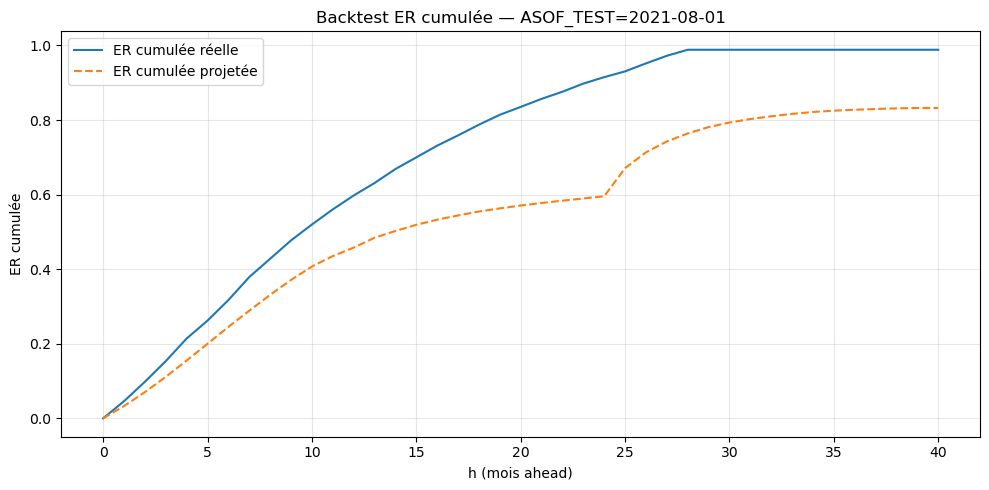

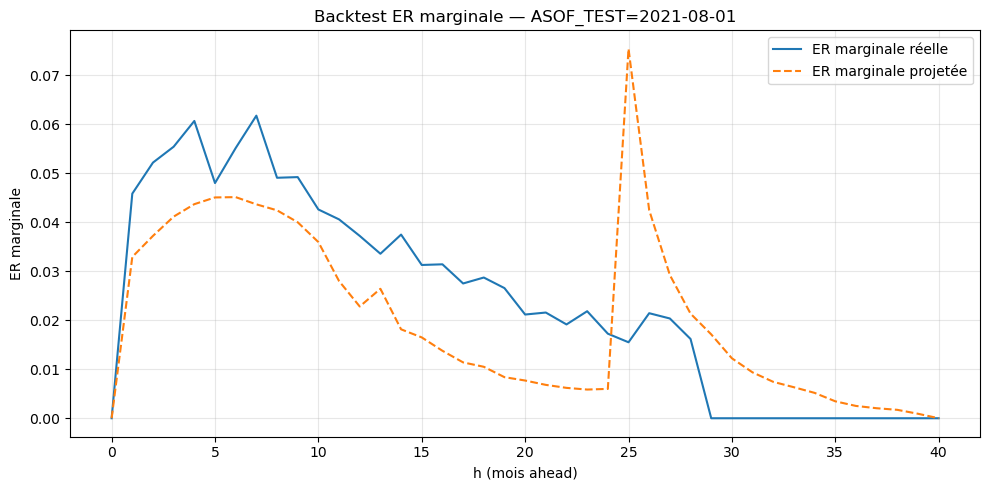

In [24]:
# =========================================================
# 1) SPLIT TRAIN / CALIB / TEST PAR ORIGINATION
# =========================================================


df_base["T_STOP_TRUE"]  = df_base["AGE_PRET"].astype("Int64")
df_base["T_STOP_PANEL"] = df_base["AGE_PRET"].clip(0, MAX_AGE).astype("Int64")

base_dates = df_base[[ID_COL, DATE_COL]].drop_duplicates().dropna()
d_train_end = base_dates[DATE_COL].quantile(Q_TRAIN_END)
d_calib_end = base_dates[DATE_COL].quantile(Q_CALIB_END)

train_ids = set(base_dates.loc[base_dates[DATE_COL] <= d_train_end, ID_COL])
calib_ids = set(base_dates.loc[(base_dates[DATE_COL] > d_train_end) & (base_dates[DATE_COL] <= d_calib_end), ID_COL]) - train_ids
test_ids  = set(base_dates.loc[base_dates[DATE_COL] > d_calib_end, ID_COL]) - train_ids - calib_ids

print("TRAIN end:", pd.to_datetime(d_train_end).date(), "| CALIB end:", pd.to_datetime(d_calib_end).date())
print("Contracts train/calib/test:", len(train_ids), len(calib_ids), len(test_ids))

# produit2 top TRAIN
top_prod = df_base.loc[df_base[ID_COL].isin(train_ids), "produit"].value_counts().head(15).index
prod_cats = list(top_prod) + ["Other"]
df_base["produit2"] = df_base["produit"].where(df_base["produit"].isin(top_prod), "Other")

# =========================================================
# 2) PANEL TRAIN (HAZARD DISCRET)
# =========================================================
panel_train = (
    df_base.loc[
        df_base[ID_COL].isin(train_ids),
        [
            ID_COL, "EVENT", "T_STOP_TRUE", "T_STOP_PANEL", DATE_COL,
            "Tx", "AGE_CLI", "produit2", "RATIO_AGE", "POST_2021"
        ]
    ]
    .dropna(subset=[ID_COL, "T_STOP_PANEL", DATE_COL, "Tx", "AGE_CLI"])
    .assign(t_int=lambda d: d["T_STOP_PANEL"].map(lambda T: list(range(int(T) + 1))))
    .explode("t_int", ignore_index=True)
)

panel_train["t_int"] = panel_train["t_int"].astype(int)

panel_train["y"] = (
    (panel_train["EVENT"] == 1)
    & panel_train["T_STOP_TRUE"].notna()
    & (panel_train["T_STOP_TRUE"] <= MAX_AGE)
    & (panel_train["t_int"] == panel_train["T_STOP_TRUE"].astype(int))
).astype(int)

panel_train["date_obs"] = (
    panel_train[DATE_COL].dt.to_period("M") + panel_train["t_int"]
).dt.to_timestamp()

panel_train = add_euribor(panel_train, e3m_full, date_obs_col="date_obs")

# structure
t_cats = list(range(0, MAX_AGE + 1))
panel_train["t_cat"] = pd.Categorical(panel_train["t_int"], categories=t_cats, ordered=True)
panel_train["regime_obs"] = pd.Categorical(
    map_regime_from_date(panel_train["date_obs"]),
    categories=REGIME_CATS
)
panel_train["produit2"] = pd.Categorical(panel_train["produit2"], categories=prod_cats)

# standardisation sur TRAIN
mu_tx,  sd_tx  = panel_train["Tx"].mean(),      panel_train["Tx"].std(ddof=0)
mu_e3m, sd_e3m = panel_train["E3M"].mean(),     panel_train["E3M"].std(ddof=0)
mu_age, sd_age = panel_train["AGE_CLI"].mean(), panel_train["AGE_CLI"].std(ddof=0)
mu_ratio, sd_ratio = panel_train["RATIO_AGE"].mean(), panel_train["RATIO_AGE"].std(ddof=0)
panel_train["ratio_age_z"] = normalize_from_params(panel_train["RATIO_AGE"], mu_ratio, sd_ratio)
panel_train["Tx_z"]      = normalize_from_params(panel_train["Tx"],      mu_tx,  sd_tx)
panel_train["E3M_z"]     = normalize_from_params(panel_train["E3M"],     mu_e3m, sd_e3m)
panel_train["AGE_CLI_z"] = normalize_from_params(panel_train["AGE_CLI"], mu_age, sd_age)

panel_train = panel_train.dropna(subset=["Tx_z", "E3M_z", "AGE_CLI_z", "regime_obs"])
print("TRAIN panel rows:", len(panel_train), "| events:", int(panel_train["y"].sum()))

# sous-echantillonnage par t
parts = []
for t_val in range(0, MAX_AGE + 1):
    g = panel_train.loc[panel_train["t_int"] == t_val]
    if len(g) == 0:
        continue
    parts.append(g.sample(n=min(len(g), PER_T), random_state=0))

train_fit = pd.concat(parts, ignore_index=True)

use_prod = train_fit["produit2"].nunique(dropna=True) > 1
if not use_prod:
    print("⚠ produit2 ignoré (une seule modalité observée dans train_fit)")

# formule compacte

#formula = "y ~ C(t_cat) + Tx_z + E3M_z + AGE_CLI_z + POST_2021 + Tx_z:E3M_z"
formula = "y ~ C(t_cat) + ratio_age_z + Tx_z + E3M_z + AGE_CLI_z + POST_2021 + Tx_z:E3M_z"
print("\nFORMULA:\n", formula)

from sklearn.linear_model import LogisticRegression

y_tr, X_tr = patsy.dmatrices(formula, data=train_fit, return_type="dataframe")
y_tr = np.ravel(y_tr)

clf = LogisticRegression(
    penalty="l2",
    C=1.0,              # à tuner
    solver="lbfgs",
    max_iter=2000,
    fit_intercept=False
)
clf.fit(X_tr, y_tr)

# fit plus leger que l'IRLS
glm_model = sm.GLM(y_tr, X_tr, family=sm.families.Binomial())
res = glm_model.fit(method="lbfgs", maxiter=MAXITER, disp=0)

print("\nConverged:", getattr(res, "converged", "NA"), "| X:", X_tr.shape)
# decommenter si tu veux le resume complet
# print(res.summary())

# =========================================================
# 3) FONCTIONS DE PREDICTION / IFRS9
# =========================================================
def predict_glm_ridge(df_in):
    if df_in is None or len(df_in) == 0:
        return np.array([])

    preds = []
    for start in range(0, len(df_in), BATCH):
        chunk = df_in.iloc[start:start + BATCH].copy()

        chunk["t_cat"] = pd.Categorical(chunk["t_int"], categories=t_cats, ordered=True)
        chunk["regime_obs"] = pd.Categorical(chunk["regime_obs"], categories=REGIME_CATS)

        if use_prod and "produit2" in chunk.columns:
            chunk["produit2"] = pd.Categorical(chunk["produit2"], categories=prod_cats)

        _, X = patsy.dmatrices(formula, data=chunk.assign(y=0), return_type="dataframe")
        preds.append(clf.predict_proba(X)[:, 1])

    return np.clip(np.concatenate(preds), 1e-9, 1 - 1e-9)
def apply_3deltas(p0, hvals, d1, d2, d3):
    p = np.clip(np.asarray(p0, float), 1e-9, 1 - 1e-9)
    hv = np.asarray(hvals, int)

    m1 = hv <= CUT1
    m2 = (hv > CUT1) & (hv <= CUT2)
    m3 = hv > CUT2

    p[m1] = expit(logit(p[m1]) + d1)
    p[m2] = expit(logit(p[m2]) + d2)
    p[m3] = expit(logit(p[m3]) + d3)
    return p

def compute_forward_curve_by_h(ids, hvals, hazards, h_max):
    p  = np.clip(np.asarray(hazards, float), 1e-9, 1 - 1e-9)
    hh = np.asarray(hvals, int)

    tmp = pd.DataFrame({ID_COL: ids, "h": hh, "p": p}).sort_values([ID_COL, "h"])

    tmp["S_cond"] = tmp.groupby(ID_COL, sort=False)["p"].transform(
        lambda s: (1 - s).cumprod()
    )
    first_S = tmp.groupby(ID_COL, sort=False)["S_cond"].transform("first")
    tmp["S_cond"] = tmp["S_cond"] / first_S

    ids_u = pd.Index(tmp[ID_COL].unique(), name=ID_COL)
    h_u   = pd.Index(np.arange(0, h_max + 1, dtype=int), name="h")
    full = pd.MultiIndex.from_product([ids_u, h_u], names=[ID_COL, "h"])

    s = (
        tmp.set_index([ID_COL, "h"])["S_cond"]
        .reindex(full)
        .groupby(level=0, sort=False)
        .ffill()
        .fillna(1.0)
    )

    S = s.groupby(level=1).mean().reset_index(name="S_t")
    S["ER_cumulee"] = 1 - S["S_t"]
    S["ER_marginal"] = S["S_t"].shift(1).fillna(1.0) - S["S_t"]
    S["ER_marginal"] = S["ER_marginal"].clip(lower=0)
    return S

def alive_ids_asof(ids_scope, asof_date):
    b = df_base.loc[df_base[ID_COL].isin(ids_scope)].copy()
    exists = b[DATE_COL].notna() & (b[DATE_COL] <= asof_date)
    alive = b[DARRET_COL].isna() | (b[DARRET_COL] > asof_date)
    return b.loc[exists & alive, ID_COL].dropna().unique()

def real_er_curve_forward(df_base_, vivant_ids, asof_date, max_h, max_age_model,
                          id_col=ID_COL, date_col=DATE_COL, darret_col=DARRET_COL):
    b = df_base_.loc[df_base_[id_col].isin(vivant_ids), [id_col, date_col, darret_col]].copy()
    b[date_col] = pd.to_datetime(b[date_col], errors="coerce")
    b[darret_col] = pd.to_datetime(b[darret_col], errors="coerce")

    age_asof = month_diff_ts(b[date_col], asof_date).astype(float)

    t_event = pd.Series(np.inf, index=b.index, dtype=float)
    m_evt = b[darret_col].notna()
    t_event.loc[m_evt] = (
        (b.loc[m_evt, darret_col].dt.year - b.loc[m_evt, date_col].dt.year) * 12
        + (b.loc[m_evt, darret_col].dt.month - b.loc[m_evt, date_col].dt.month)
    ).astype(float).values

    h_evt = t_event - age_asof

    h_grid = np.arange(0, max_h + 1, dtype=int)
    er_cum = []
    for h in h_grid:
        er_cum.append(np.mean((h_evt >= 0) & (h_evt <= h) & (t_event <= max_age_model)))

    out = pd.DataFrame({"h": h_grid, "ER_cumulee_real": er_cum})
    out["ER_marginal_real"] = out["ER_cumulee_real"].diff().fillna(out["ER_cumulee_real"])
    out["ER_marginal_real"] = out["ER_marginal_real"].clip(lower=0)
    return out

def build_panel_asof(vivant_ids, asof_date, h_max):
    b = df_base.loc[df_base[ID_COL].isin(vivant_ids)].copy()
    b = b.dropna(subset=[ID_COL, DATE_COL, "Tx", "AGE_CLI", "produit2", "RATIO_AGE"]).copy()

    b["AGE_ACTUEL_ASOF"] = month_diff_ts(b[DATE_COL], asof_date).astype("Int64")

    b = b.loc[
        b["AGE_ACTUEL_ASOF"].notna()
        & (b["AGE_ACTUEL_ASOF"] >= 0)
        & (b["AGE_ACTUEL_ASOF"] <= MAX_AGE)
    ].copy()

    if len(b) == 0:
        return b

    b["h_list"] = b["AGE_ACTUEL_ASOF"].map(
        lambda a: list(range(0, min(h_max, MAX_AGE - int(a)) + 1))
    )

    proj = (
        b[
            [
                ID_COL, DATE_COL, "Tx", "AGE_CLI", "produit2",
                "RATIO_AGE", "POST_2021", "AGE_ACTUEL_ASOF", "h_list"
            ]
        ]
        .explode("h_list", ignore_index=True)
        .rename(columns={"h_list": "h"})
    )

    proj["h"] = proj["h"].astype(int)
    proj["t_int"] = (proj["AGE_ACTUEL_ASOF"].astype(int) + proj["h"]).astype(int)

    proj["date_obs"] = (
        proj[DATE_COL].dt.to_period("M") + proj["t_int"]
    ).dt.to_timestamp()

    proj = add_euribor(proj, e3m_full, date_obs_col="date_obs")

    proj["ratio_age_z"] = normalize_from_params(proj["RATIO_AGE"], mu_ratio, sd_ratio)
    proj["Tx_z"] = normalize_from_params(proj["Tx"], mu_tx, sd_tx)
    proj["E3M_z"] = normalize_from_params(proj["E3M"], mu_e3m, sd_e3m)
    proj["AGE_CLI_z"] = normalize_from_params(proj["AGE_CLI"], mu_age, sd_age)

    proj["t_cat"] = pd.Categorical(proj["t_int"], categories=t_cats, ordered=True)
    proj["regime_obs"] = pd.Categorical(
        map_regime_from_date(proj["date_obs"]),
        categories=REGIME_CATS
    )

    if use_prod:
        proj["produit2"] = pd.Categorical(proj["produit2"], categories=prod_cats)

    proj = proj.dropna(subset=["Tx_z", "E3M_z", "AGE_CLI_z", "regime_obs", "ratio_age_z"])
    return proj

# =========================================================
# 4) CALIBRATION IFRS9 SUR CALIB
# =========================================================
ASOF_CALIB = pd.to_datetime(d_calib_end).to_period("M").to_timestamp()
H_MAX = MAX_AGE

alive_calib = alive_ids_asof(calib_ids, ASOF_CALIB)
print("\nASOF_CALIB:", ASOF_CALIB.date(), "| alive CALIB:", len(alive_calib))

panel_calib = build_panel_asof(alive_calib, ASOF_CALIB, H_MAX)
if len(panel_calib) == 0:
    raise ValueError("Aucun contrat scoré sur CALIB après filtrage.")

scored_calib_ids = pd.unique(panel_calib[ID_COL])
print("Scored CALIB:", len(scored_calib_ids))

p0_calib = predict_glm_ridge(panel_calib)

ids_c = panel_calib[ID_COL].values
h_c   = panel_calib["h"].values

real_cal = real_er_curve_forward(
    df_base_=df_base,
    vivant_ids=scored_calib_ids,
    asof_date=ASOF_CALIB,
    max_h=H_MAX,
    max_age_model=MAX_AGE
)

tgt12 = float(real_cal.loc[real_cal["h"] == CUT1, "ER_cumulee_real"].iloc[0])
tgt24 = float(real_cal.loc[real_cal["h"] == CUT2, "ER_cumulee_real"].iloc[0])
tgt40 = float(real_cal.loc[real_cal["h"] == H_MAX, "ER_cumulee_real"].iloc[0])

print("Targets CALIB (réel RA): h12=", tgt12, "h24=", tgt24, "h40=", tgt40)

def er_at_h(d1, d2, d3, h_chk):
    p = apply_3deltas(p0_calib, h_c, d1, d2, d3)
    curve = compute_forward_curve_by_h(ids_c, h_c, p, H_MAX)
    return float(curve.loc[curve["h"] == h_chk, "ER_cumulee"].iloc[0])

def bisect_d(which, d1_fix=0.0, d2_fix=0.0):
    lo, hi = -15.0, 15.0
    for _ in range(60):
        mid = (lo + hi) / 2

        if which == 1:
            v = er_at_h(mid, 0.0, 0.0, CUT1)
            if v < tgt12:
                lo = mid
            else:
                hi = mid

        elif which == 2:
            v = er_at_h(d1_fix, mid, 0.0, CUT2)
            if v < tgt24:
                lo = mid
            else:
                hi = mid

        else:
            v = er_at_h(d1_fix, d2_fix, mid, H_MAX)
            if v < tgt40:
                lo = mid
            else:
                hi = mid

    return (lo + hi) / 2

d1 = bisect_d(1)
d2 = bisect_d(2, d1_fix=d1)
d3 = bisect_d(3, d1_fix=d1, d2_fix=d2)

print("\nDeltas IFRS9:", d1, d2, d3)

# =========================================================
# 5) BACKTEST TEST
# =========================================================
ASOF_TEST = (pd.to_datetime(d_calib_end).to_period("M").to_timestamp() + pd.DateOffset(months=12))
ASOF_TEST = ASOF_TEST.to_period("M").to_timestamp()

print("\nASOF_TEST:", ASOF_TEST.date())

alive_test = alive_ids_asof(test_ids, ASOF_TEST)
print("alive TEST:", len(alive_test))

panel_test = build_panel_asof(alive_test, ASOF_TEST, H_MAX)
if len(panel_test) == 0:
    raise ValueError("Aucun contrat scoré sur TEST après filtrage.")

scored_test_ids = pd.unique(panel_test[ID_COL])
print("Scored TEST:", len(scored_test_ids))

p0_test = predict_glm_ridge(panel_test)

ids_t = panel_test[ID_COL].values
h_t   = panel_test["h"].values

p_test = apply_3deltas(p0_test, h_t, d1, d2, d3)

proj_test = compute_forward_curve_by_h(ids_t, h_t, p_test, H_MAX).rename(
    columns={
        "ER_cumulee": "ER_cumulee_proj",
        "ER_marginal": "ER_marginal_proj"
    }
)

real_test = real_er_curve_forward(
    df_base_=df_base,
    vivant_ids=scored_test_ids,
    asof_date=ASOF_TEST,
    max_h=H_MAX,
    max_age_model=MAX_AGE
)

cmp = (
    real_test.merge(
        proj_test[["h", "ER_cumulee_proj", "ER_marginal_proj"]],
        on="h",
        how="inner"
    )
    .sort_values("h")
    .reset_index(drop=True)
)

mae = (cmp["ER_marginal_real"] - cmp["ER_marginal_proj"]).abs().mean()
rmse = np.sqrt(((cmp["ER_marginal_real"] - cmp["ER_marginal_proj"]) ** 2).mean())

print("\nBACKTEST TEST:")
print("MAE:", mae, "RMSE:", rmse)
print("Fin h40 real/proj:", float(cmp["ER_cumulee_real"].iloc[-1]), float(cmp["ER_cumulee_proj"].iloc[-1]))

# =========================================================
# 6) PLOTS
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(cmp["h"], cmp["ER_cumulee_real"], label="ER cumulée réelle")
plt.plot(cmp["h"], cmp["ER_cumulee_proj"], "--", label="ER cumulée projetée")
plt.xlabel("h (mois ahead)")
plt.ylabel("ER cumulée")
plt.title(f"Backtest ER cumulée — ASOF_TEST={ASOF_TEST.date()}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cmp["h"], cmp["ER_marginal_real"], label="ER marginale réelle")
plt.plot(cmp["h"], cmp["ER_marginal_proj"], "--", label="ER marginale projetée")
plt.xlabel("h (mois ahead)")
plt.ylabel("ER marginale")
plt.title(f"Backtest ER marginale — ASOF_TEST={ASOF_TEST.date()}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### amelio